1) Imports

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer

import matplotlib.pyplot as plt
import joblib


2) Load Dataset + Temporal Split

In [6]:
train_df = pd.read_csv("train_data.csv")
test_df  = pd.read_csv("Test_Data.csv")

In [7]:
X_train = train_df.drop("popularity", axis=1)
y_train = train_df["popularity"]

In [8]:
X_test  = test_df.drop("popularity", axis=1)
y_test  = test_df["popularity"]

3) Scaling

In [9]:
scaler = StandardScaler()

In [10]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [11]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

4) Random Forest + Feature Importance + Plot

In [12]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

In [13]:
rf.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=20, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [14]:
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [15]:
rf_pred = rf.predict(X_test_scaled)

In [16]:
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest R2 :", r2_score(y_test, rf_pred))

Random Forest MAE: 12.229309026017676
Random Forest R2 : 0.630304705424727


In [17]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

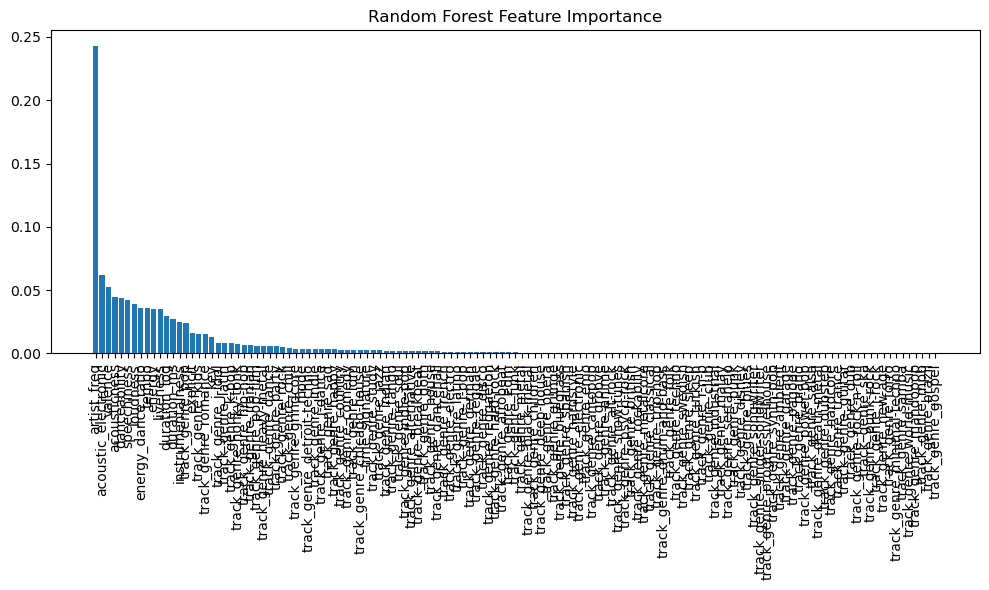

In [18]:
plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

5) Temporal Cross-Validation on Train Data

In [19]:
tscv = TimeSeriesSplit(n_splits=5)

In [20]:
scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [21]:
print("Temporal CV MAE per fold:", -scores)
print("Avg Temporal CV MAE:", -scores.mean())

Temporal CV MAE per fold: [14.30564612 13.58200653 12.88946963 12.33269254 12.48592685]
Avg Temporal CV MAE: 13.119148333656284


6) XGBoost – Bayesian Optimization (Optuna)

In [22]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    n_estimators=500,
    random_state=42
)

In [23]:
search_space = {
    "learning_rate": Real(0.01, 0.3),
    "max_depth": Integer(3, 12),
    "min_child_weight": Integer(1, 10),
    "subsample": Real(0.5, 1.0),
    "colsample_bytree": Real(0.5, 1.0)
}

In [24]:
opt = BayesSearchCV(
    estimator=xgb,
    search_spaces=search_space,
    cv=TimeSeriesSplit(n_splits=3),
    n_iter=20,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

In [25]:
opt.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

BayesSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
              estimator=XGBRegressor(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mae', feature_types=None,
                                     feature_weights=None, gamma=No...
              search_spaces={'colsample_bytree': Real(low=0.5, high=1.0, prior='uniform', transform='normalize'),
                             'learning_rate': Real(low=0.01, high=0.3, prior='uniform', transform='normalize'),
                             'max_depth': Integer(low=3, high=12, prior='uniform', transform='normalize'),
                             'min_child_weight': Integer(low=1, high=10, prior='uniform', transform='normalize'),
                             'subsample': Real(low=0.5, high=1.0, prior='uniform', transform='normalize')},
              verbose=1)

In [26]:
best_xgb = opt.best_estimator_
joblib.dump(best_xgb, "xgboost_best.pkl")

['xgboost_best.pkl']

In [27]:
xgb_pred = best_xgb.predict(X_test_scaled)

In [28]:
print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))
print("XGBoost R2 :", r2_score(y_test, xgb_pred))

XGBoost MAE: 4.328162955193411
XGBoost R2 : 0.8672741651535034


7) Plot Predicted vs Actual

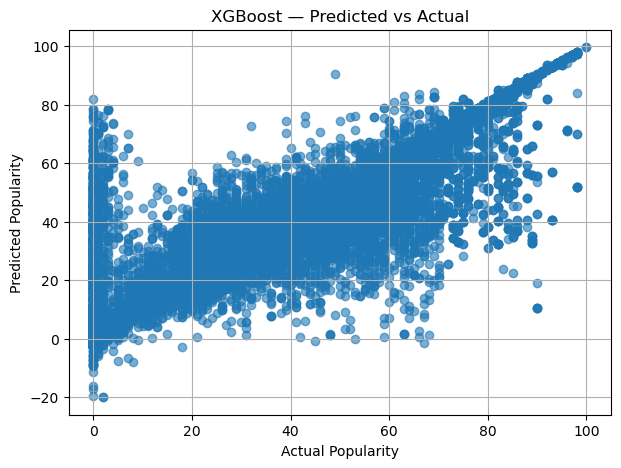

In [29]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, xgb_pred, alpha=0.6)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("XGBoost — Predicted vs Actual")
plt.grid(True)
plt.show()

8) Save Final Results

In [30]:
results = pd.DataFrame({
    "actual": y_test,
    "rf_pred": rf_pred,
    "xgb_pred": xgb_pred
})

In [31]:
results.to_csv("final_predictions.csv", index=False)
print("Saved final_predictions.csv")

Saved final_predictions.csv
